# Medical Billing Research Project
## 03c — Random Forest Model

**Loads from:** ../dataset/train_set.csv
**Evaluates on:** ../dataset/test_set.csv
**Target variable:** Processing Class (Timely / Delayed)
**Predictors:** 6 categorical variables

### Objective
Build a Random Forest ensemble model. Random Forest builds
500 decision trees on bootstrap samples of the training data
and combines their predictions through majority voting.
It provides a built-in variable importance measure based on
mean Gini impurity reduction across all trees — this directly
addresses our objective of identifying which factors most
strongly predict processing delays.

In [1]:
# ============================================================
# CELL 1: IMPORTS AND LOAD DATA
# Random Forest does not require feature scaling.
# It uses threshold-based splits like Decision Tree so
# the scale of variables does not affect performance.
# We apply One-Hot Encoding as scikit-learn requires
# numeric input for all its estimators.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, f1_score
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load data ─────────────────────────────────────────────
train = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
test = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)

# ── Separate predictors and target ───────────────────────
X_train = train.drop(columns=['Invoice Number', 'Processing Class'])
y_train = train['Processing Class']
X_test  = test.drop(columns=['Invoice Number', 'Processing Class'])
y_test  = test['Processing Class']

# ── One-Hot Encoding ──────────────────────────────────────
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)

# Align columns between train and test
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0
)

# Encode target — Delayed = 1, Timely = 0
y_train_enc = (y_train == 'Delayed').astype(int)
y_test_enc  = (y_test  == 'Delayed').astype(int)

print("=" * 60)
print("DATA LOADED AND ENCODED — RANDOM FOREST")
print("=" * 60)
print(f"  Training records  : {len(X_train_enc):,}")
print(f"  Test records      : {len(X_test_enc):,}")
print(f"  Encoded columns   : {X_train_enc.shape[1]}")
print(f"  Columns match     : "
      f"{list(X_train_enc.columns) == list(X_test_enc.columns)}")
print(f"\n  Training target:")
print(f"    Delayed = 1 : {y_train_enc.sum():,}")
print(f"    Timely  = 0 : {(y_train_enc==0).sum():,}")

DATA LOADED AND ENCODED — RANDOM FOREST
  Training records  : 35,000
  Test records      : 15,000
  Encoded columns   : 43
  Columns match     : True

  Training target:
    Delayed = 1 : 8,427
    Timely  = 0 : 26,573


In [2]:
# ============================================================
# CELL 2: FIT RANDOM FOREST MODEL
# n_estimators=500 — we build 500 decision trees.
# More trees generally improves stability and performance
# at the cost of computation time. 500 is the standard
# recommendation for classification tasks.
# max_features='sqrt' — at each split only the square root
# of total features is considered. With 43 encoded features
# this means approximately 6-7 features per split.
# This is the standard recommendation for classification
# as stated in Breiman (2001).
# class_weight='balanced' — adjusts for the 75.9/24.1
# class imbalance by upweighting the minority Delayed class.
# n_jobs=-1 — uses all available CPU cores to speed up
# training across 500 trees.
# random_state=42 — ensures reproducibility.
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

print("=" * 60)
print("RANDOM FOREST — FITTING MODEL")
print("This may take a moment with 500 trees...")
print("=" * 60)

rf_model.fit(X_train_enc, y_train_enc)

print(f"\n  Model fitted successfully")
print(f"  Number of trees     : {rf_model.n_estimators}")
print(f"  Features per split  : {rf_model.max_features}")
print(f"  Class weight        : {rf_model.class_weight}")
print(f"  Number of features  : {rf_model.n_features_in_}")

# ── Generate predictions ──────────────────────────────────
y_pred       = rf_model.predict(X_test_enc)
y_pred_proba = rf_model.predict_proba(X_test_enc)[:, 1]

# ── Evaluate on test set ──────────────────────────────────
accuracy   = accuracy_score(y_test_enc, y_pred)
auc        = roc_auc_score(y_test_enc, y_pred_proba)
f1_delayed = f1_score(y_test_enc, y_pred, pos_label=1)
cm         = confusion_matrix(y_test_enc, y_pred)
report     = classification_report(
    y_test_enc, y_pred,
    target_names=['Timely', 'Delayed'],
    digits=4
)

print(f"\n{'=' * 60}")
print("RANDOM FOREST — TEST SET EVALUATION")
print("=" * 60)
print(f"\n  Accuracy        : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  ROC-AUC         : {auc:.4f}")
print(f"  F1 (Delayed)    : {f1_delayed:.4f}")
print(f"\n  Classification Report:")
print(report)
print(f"  Confusion Matrix:")
print(f"                  Predicted Timely  Predicted Delayed")
print(f"  Actual Timely   {cm[0,0]:>15,}  {cm[0,1]:>17,}")
print(f"  Actual Delayed  {cm[1,0]:>15,}  {cm[1,1]:>17,}")
print(f"\n  Breakdown:")
print(f"    True Negatives  (Timely correctly predicted)  : {cm[0,0]:,}")
print(f"    False Positives (Timely predicted as Delayed) : {cm[0,1]:,}")
print(f"    False Negatives (Delayed predicted as Timely) : {cm[1,0]:,}")
print(f"    True Positives  (Delayed correctly predicted) : {cm[1,1]:,}")

RANDOM FOREST — FITTING MODEL
This may take a moment with 500 trees...

  Model fitted successfully
  Number of trees     : 500
  Features per split  : sqrt
  Class weight        : balanced
  Number of features  : 43

RANDOM FOREST — TEST SET EVALUATION

  Accuracy        : 0.6862 (68.62%)
  ROC-AUC         : 0.7550
  F1 (Delayed)    : 0.5144

  Classification Report:
              precision    recall  f1-score   support

      Timely     0.8746    0.6849    0.7682     11389
     Delayed     0.4099    0.6904    0.5144      3611

    accuracy                         0.6862     15000
   macro avg     0.6423    0.6876    0.6413     15000
weighted avg     0.7628    0.6862    0.7071     15000

  Confusion Matrix:
                  Predicted Timely  Predicted Delayed
  Actual Timely             7,800              3,589
  Actual Delayed            1,118              2,493

  Breakdown:
    True Negatives  (Timely correctly predicted)  : 7,800
    False Positives (Timely predicted as Delayed) 

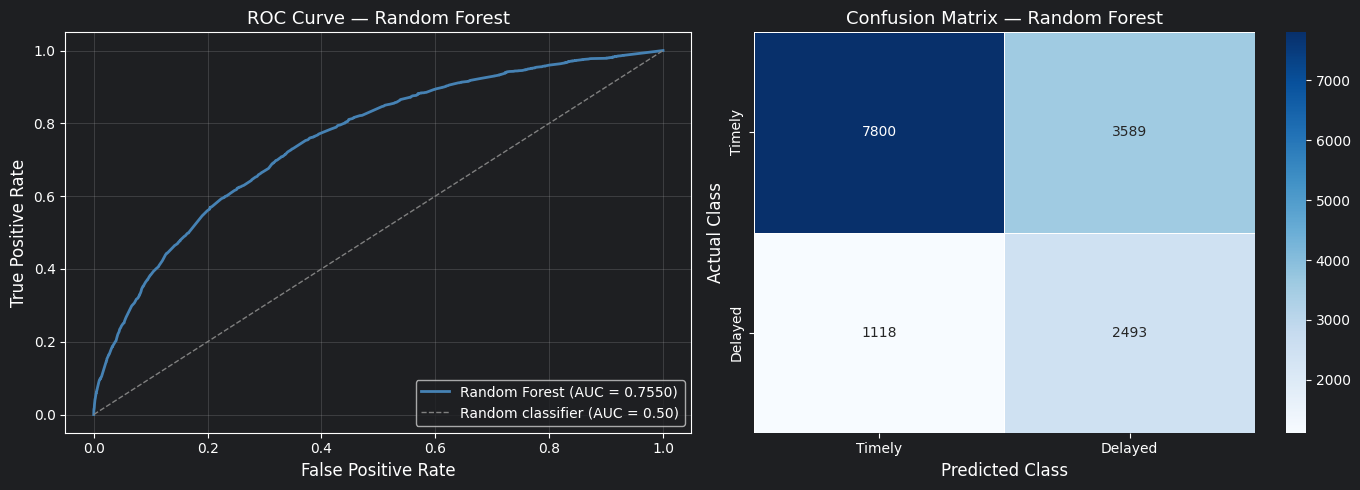

ROC and confusion matrix saved to outputs/figures/
VARIABLE IMPORTANCE — RANDOM FOREST
Mean Gini impurity reduction across 500 trees

  Variable                         Importance   % of Total
  ------------------------------------------------------
  Specialty                            0.1988        19.9%
  Facility Type                        0.1825        18.2%
  ICD10 Chapter                        0.1770        17.7%
  Posted Billing Group                 0.1762        17.6%
  Age Bracket                          0.1710        17.1%
  Debtor Status                        0.0945         9.4%


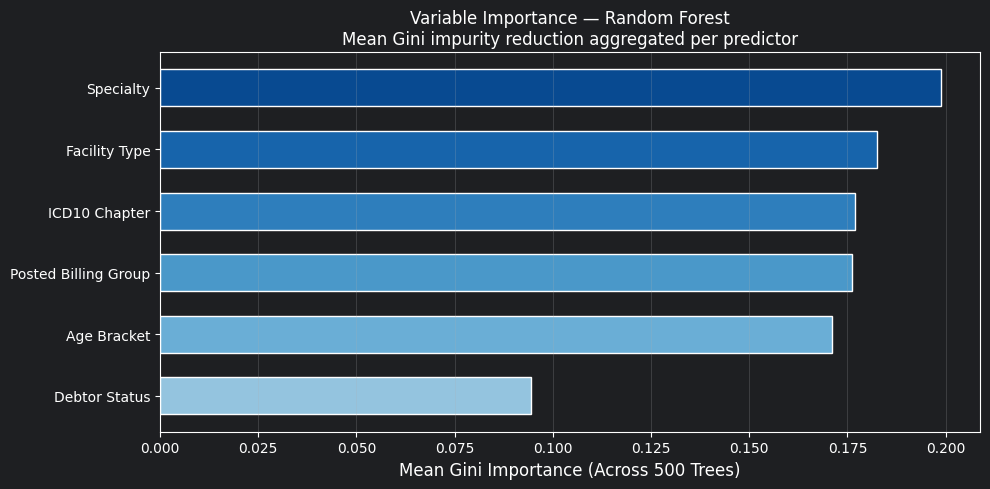

Variable importance plot saved to outputs/figures/


In [3]:
# ============================================================
# CELL 3: VISUALIZATIONS AND VARIABLE IMPORTANCE
# Random Forest variable importance is the most reliable
# of the three models — it averages Gini reduction across
# 500 trees which reduces the variance of individual
# tree splits and gives a more stable importance ranking.
# We aggregate from encoded column level back to original
# variable level for clean interpretation.
# ============================================================

# ── Plot 1: ROC Curve and Confusion Matrix ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test_enc, y_pred_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Random Forest (AUC = {auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='grey', lw=1,
             linestyle='--',
             label='Random classifier (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Random Forest', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

cm_labels = ['Timely', 'Delayed']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels,
            ax=axes[1], cbar=True, linewidths=0.5)
axes[1].set_xlabel('Predicted Class', fontsize=12)
axes[1].set_ylabel('Actual Class', fontsize=12)
axes[1].set_title('Confusion Matrix — Random Forest',
                  fontsize=13)

plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\rf_roc_confusion.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("ROC and confusion matrix saved to outputs/figures/")

# ── Variable Importance ───────────────────────────────────
# Average Gini reduction across all 500 trees
importance_df = pd.DataFrame({
    'Feature':    X_train_enc.columns,
    'Importance': rf_model.feature_importances_
})

# Aggregate back to original variable level
def get_original_variable(col):
    predictors = [
        'Posted Billing Group', 'Specialty',
        'Debtor Status', 'ICD10 Chapter', 'Facility Type'
    ]
    for pred in predictors:
        if col.startswith(pred):
            return pred
    return col

importance_df['Original Variable'] = (
    importance_df['Feature'].apply(get_original_variable)
)

var_importance = (
    importance_df.groupby('Original Variable')['Importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("=" * 60)
print("VARIABLE IMPORTANCE — RANDOM FOREST")
print("Mean Gini impurity reduction across 500 trees")
print("=" * 60)
print(f"\n  {'Variable':<30} {'Importance':>12} {'% of Total':>12}")
print(f"  {'-'*54}")
total_imp = var_importance['Importance'].sum()
for _, row in var_importance.iterrows():
    pct = row['Importance'] / total_imp * 100
    print(f"  {row['Original Variable']:<30} "
          f"{row['Importance']:>12.4f} "
          f"{pct:>11.1f}%")

# ── Plot variable importance ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(var_importance))
)[::-1]

ax.barh(var_importance['Original Variable'],
        var_importance['Importance'],
        color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Mean Gini Importance (Across 500 Trees)',
              fontsize=12)
ax.set_title(
    'Variable Importance — Random Forest\n'
    'Mean Gini impurity reduction aggregated per predictor',
    fontsize=12)
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\rf_variable_importance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Variable importance plot saved to outputs/figures/")

In [4]:
# ============================================================
# CELL 4: SAVE RANDOM FOREST RESULTS
# Save metrics, predictions and variable importance
# for use in the model comparison notebook.
# ============================================================

# ── Save metrics ──────────────────────────────────────────
rf_results = {
    'model':             'Random Forest',
    'n_estimators':      500,
    'accuracy':          round(accuracy, 4),
    'auc':               round(auc, 4),
    'f1_delayed':        round(f1_delayed, 4),
    'precision_delayed': round(
        cm[1,1] / (cm[0,1] + cm[1,1]), 4),
    'recall_delayed':    round(
        cm[1,1] / (cm[1,0] + cm[1,1]), 4),
    'true_negatives':    int(cm[0,0]),
    'false_positives':   int(cm[0,1]),
    'false_negatives':   int(cm[1,0]),
    'true_positives':    int(cm[1,1]),
}

with open(
    r'C:\2026\MedicalBillingResearch\models'
    r'\rf_metrics.json', 'w'
) as f:
    json.dump(rf_results, f, indent=4)

# ── Save predictions ──────────────────────────────────────
pd.DataFrame({
    'y_true':       y_test_enc,
    'y_pred':       y_pred,
    'y_pred_proba': y_pred_proba
}).to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\rf_predictions.csv',
    index=False
)

# ── Save variable importance ──────────────────────────────
var_importance.to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\rf_variable_importance.csv',
    index=False
)

print("=" * 60)
print("RANDOM FOREST RESULTS SAVED")
print("=" * 60)
print(f"\n  Metrics saved     : models/rf_metrics.json")
print(f"  Predictions saved : models/rf_predictions.csv")
print(f"  Importance saved  : models/rf_variable_importance.csv")
print(f"\n  Summary:")
for key, val in rf_results.items():
    print(f"    {key:<25} : {val}")

print(f"\n  Random Forest notebook — COMPLETE")
print(f"  Next: 03d_model_comparison.ipynb")

RANDOM FOREST RESULTS SAVED

  Metrics saved     : models/rf_metrics.json
  Predictions saved : models/rf_predictions.csv
  Importance saved  : models/rf_variable_importance.csv

  Summary:
    model                     : Random Forest
    n_estimators              : 500
    accuracy                  : 0.6862
    auc                       : 0.755
    f1_delayed                : 0.5144
    precision_delayed         : 0.4099
    recall_delayed            : 0.6904
    true_negatives            : 7800
    false_positives           : 3589
    false_negatives           : 1118
    true_positives            : 2493

  Random Forest notebook — COMPLETE
  Next: 03d_model_comparison.ipynb
